In [25]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
url = "http://books.toscrape.com/"

response = requests.get(url)

print(response.status_code)
print(response.text[:500])

200
<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" /


In [4]:
soup = BeautifulSoup(response.text, "html.parser")

print(soup.title)

<title>
    All products | Books to Scrape - Sandbox
</title>


In [5]:
books = soup.find_all("article", class_="product_pod")

print(len(books))

20


In [7]:
first_book = books[0]

print(first_book)

<article class="product_pod">
<div class="image_container">
<a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
</div>
<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
<div class="product_price">
<p class="price_color">Â£51.77</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>


In [8]:
title = first_book.h3.a["title"]
print(title)

A Light in the Attic


In [9]:
price = first_book.find("p", class_="price_color").text
print(price)

Â£51.77


In [10]:
rating = first_book.find("p", class_="star-rating")["class"]
print(rating)

['star-rating', 'Three']


In [11]:
rating = rating[1]

In [12]:
book_data = []

for book in books:
    title = book.h3.a["title"]
    price = book.find("p", class_="price_color").text
    rating = book.find("p", class_="star-rating")["class"][1]

    book_data.append({
        "title": title,
        "price": price,
        "rating": rating
    })

print(book_data)

[{'title': 'A Light in the Attic', 'price': 'Â£51.77', 'rating': 'Three'}, {'title': 'Tipping the Velvet', 'price': 'Â£53.74', 'rating': 'One'}, {'title': 'Soumission', 'price': 'Â£50.10', 'rating': 'One'}, {'title': 'Sharp Objects', 'price': 'Â£47.82', 'rating': 'Four'}, {'title': 'Sapiens: A Brief History of Humankind', 'price': 'Â£54.23', 'rating': 'Five'}, {'title': 'The Requiem Red', 'price': 'Â£22.65', 'rating': 'One'}, {'title': 'The Dirty Little Secrets of Getting Your Dream Job', 'price': 'Â£33.34', 'rating': 'Four'}, {'title': 'The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull', 'price': 'Â£17.93', 'rating': 'Three'}, {'title': 'The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics', 'price': 'Â£22.60', 'rating': 'Four'}, {'title': 'The Black Maria', 'price': 'Â£52.15', 'rating': 'One'}, {'title': 'Starving Hearts (Triangular Trade Trilogy, #1)', 'price': 'Â£13.99', 'rating': 'Two'}, {'title': "Sha

In [14]:
df = pd.DataFrame(book_data)

print(df.head())

                                   title    price rating
0                   A Light in the Attic  Â£51.77  Three
1                     Tipping the Velvet  Â£53.74    One
2                             Soumission  Â£50.10    One
3                          Sharp Objects  Â£47.82   Four
4  Sapiens: A Brief History of Humankind  Â£54.23   Five


In [15]:
df["price"] = df["price"].str.replace("Â£", "", regex=False).astype(float)

In [16]:
print(df.head())
print(df.dtypes)

                                   title  price rating
0                   A Light in the Attic  51.77  Three
1                     Tipping the Velvet  53.74    One
2                             Soumission  50.10    One
3                          Sharp Objects  47.82   Four
4  Sapiens: A Brief History of Humankind  54.23   Five
title      object
price     float64
rating     object
dtype: object


In [17]:
book_data = []

for page in range(1, 51):

    url = f"http://books.toscrape.com/catalogue/page-{page}.html"
    
    response = requests.get(url)
    
    soup = BeautifulSoup(response.text, "html.parser")
    
    books = soup.find_all("article", class_="product_pod")
    
    for book in books:
        
        title = book.h3.a["title"]
        price = book.find("p", class_="price_color").text
        rating = book.find("p", class_="star-rating")["class"][1]
        
        book_data.append({
            "title": title,
            "price": price,
            "rating": rating
        })

df = pd.DataFrame(book_data)

df["price"] = df["price"].str.replace("Â£", "", regex=False).astype(float)

print(df.shape)

(1000, 3)


In [18]:
df.head()

,title,price,rating
0,A Light in the Attic,51.77,Three
1,Tipping the Velvet,53.74,One
2,Soumission,50.10,One
3,Sharp Objects,47.82,Four
4,Sapiens: A Brief History of Humankind,54.23,Five


In [19]:
print(df["rating"].unique())

['Three' 'One' 'Four' 'Five' 'Two']


In [20]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["rating"] = df["rating"].map(rating_map)

In [21]:
print(df.head())
print(df.dtypes)

                                   title  price  rating
0                   A Light in the Attic  51.77       3
1                     Tipping the Velvet  53.74       1
2                             Soumission  50.10       1
3                          Sharp Objects  47.82       4
4  Sapiens: A Brief History of Humankind  54.23       5
title      object
price     float64
rating      int64
dtype: object


In [22]:
avg_price = df["price"].mean()
print(f"Average book price: £{avg_price:.2f}")

Average book price: £35.07


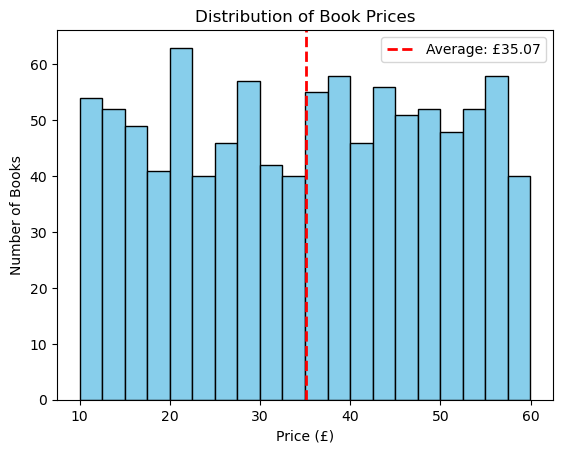

In [30]:
plt.hist(df["price"], bins=20, color="skyblue", edgecolor="black")
plt.axvline(avg_price, color="red", linestyle="dashed", linewidth=2, label=f'Average: £{avg_price:.2f}')
plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.legend()
plt.show()

In [23]:
rating_counts = df["rating"].value_counts().sort_index()
print(rating_counts)

rating
1    226
2    196
3    203
4    179
5    196
Name: count, dtype: int64


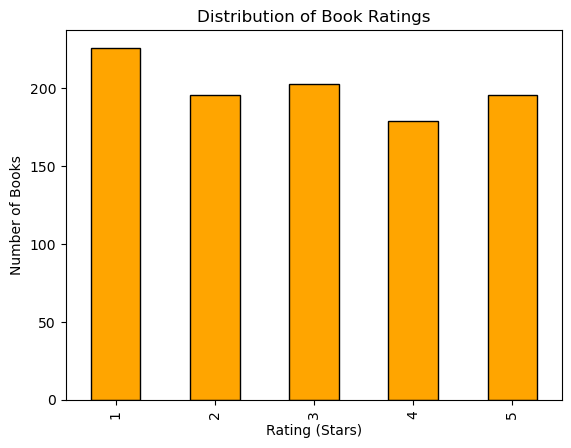

In [31]:
rating_counts.plot(kind="bar", color="orange", edgecolor="black")
plt.title("Distribution of Book Ratings")
plt.xlabel("Rating (Stars)")
plt.ylabel("Number of Books")
plt.show()

In [24]:
avg_price_by_rating = df.groupby("rating")["price"].mean()
print(avg_price_by_rating)

rating
1    34.561195
2    34.810918
3    34.692020
4    36.093296
5    35.374490
Name: price, dtype: float64


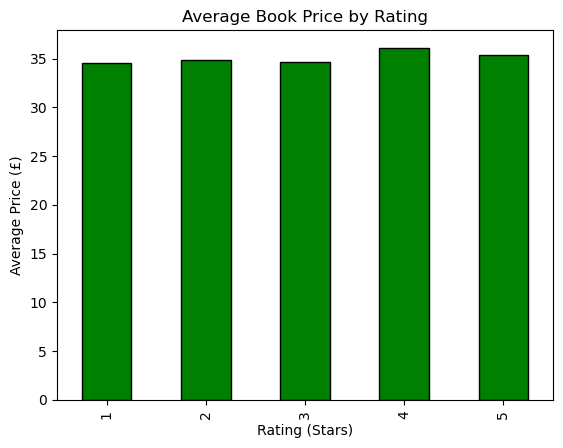

In [32]:
avg_price_by_rating.plot(kind="bar", color="green", edgecolor="black")
plt.title("Average Book Price by Rating")
plt.xlabel("Rating (Stars)")
plt.ylabel("Average Price (£)")
plt.show()